# CNN Architectures

In [1]:
# CONFIG
FAST_RUN = True  # pon False si quieres ejecutar TODO (descargas/entreno completo)



In this notebook, we are going to implement a state-of-the-art convolutional neural network. You can use PyTorch, Keras, or TensorFlow for this purpose. However, you should provide a summary of the created network at the end. You have to implement an architecture between AlexNet and VGG19 and another architecture between Resnet50 and Inception v1.

### Ejemplo de summary (solo ilustrativo)

Este bloque estaba como *code cell* y provocaba `SyntaxError`. Lo dejamos como ejemplo en texto.


## [VGG19 Architecture ](https://arxiv.org/pdf/1409.1556.pdf)

[![VGG19](https://drive.google.com/uc?export=view&id=1RVNnaJexXo1DmQGdLN-JIs6NwJDR9Ikb)](https://drive.google.com/uc?export=view&id=1RVNnaJexXo1DmQGdLN-JIs6NwJDR9Ikb)



## [AlexNet Architecture](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

[![AlexNet](https://drive.google.com/uc?export=view&id=1oQyk0IPqSsc5P2fAZXMplfcrEsHI_MUR)](https://drive.google.com/uc?export=view&id=1oQyk0IPqSsc5P2fAZXMplfcrEsHI_MUR)

## [Resnet50 Architecture](https://arxiv.org/abs/1512.03385)

[![Resnet50](https://drive.google.com/uc?export=view&id=1bMm3lrl8hQjVz1epH6WwEC24RFtMMUFo)](https://drive.google.com/uc?export=view&id=1bMm3lrl8hQjVz1epH6WwEC24RFtMMUFo)

## [Inception v3 Architecture](https://arxiv.org/abs/1512.00567v3)

[![Inception v1](https://drive.google.com/uc?export=view&id=1n-_IIBxsXviJRxH9Be6L2at6cnzzzuAq)](https://drive.google.com/uc?export=view&id=1n-_IIBxsXviJRxH9Be6L2at6cnzzzuAq)

## **First Implementation:**

In [2]:
import torch
import torch.nn as nn

class VGG(nn.Module):
    """
    Implementación manual de VGG19 siguiendo la arquitectura del paper
    'Very Deep Convolutional Networks for Large-Scale Image Recognition'
    (Simonyan & Zisserman, 2014).

    Atributos:
        features (nn.Sequential): 5 bloques convolucionales con filtros 3x3.
        avgpool (nn.AdaptiveAvgPool2d): Pooling adaptativo para salida fija de 7x7.
        classifier (nn.Sequential): 3 capas fully-connected para clasificación.
    """
    def __init__(self, num_classes=1000):
        super(VGG, self).__init__()
                                                                                            # Input: [batch, 3, 224, 224]
        self.features = nn.Sequential(
            # Bloque 1: 2 capas conv de 64 filtros 3x3
            nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),            # [batch, 64, 224, 224]
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),           # [batch, 64, 224, 224]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 64, 112, 112]

            # Bloque 2: 2 capas conv de 128 filtros 3x3
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),          # [batch, 128, 112, 112]
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 128, 112, 112]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 128, 56, 56]

            # Bloque 3: 4 capas conv de 256 filtros 3x3 (VGG19 tiene 4, VGG16 tiene 3)
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 256, 28, 28]

            # Bloque 4: 4 capas conv de 512 filtros 3x3
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 512, 14, 14]

            # Bloque 5: 4 capas conv de 512 filtros 3x3
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 512, 7, 7]
        )

        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(7, 7))                            # [batch, 512, 7, 7]

        self.classifier = nn.Sequential(
            nn.Linear(in_features=512 * 7 * 7, out_features=4096, bias=True),               # [batch, 4096]
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            nn.Linear(in_features=4096, out_features=4096, bias=True),                       # [batch, 4096]
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            nn.Linear(in_features=4096, out_features=num_classes, bias=True),                # [batch, num_classes]
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Instanciar y mostrar resumen de la arquitectura
my_vgg19 = VGG(num_classes=1000)
print(my_vgg19)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

## **Second Implementation:**

In [3]:
class Bottleneck(nn.Module):
    """
    Bloque Bottleneck para ResNet.
    Arquitectura: conv1x1 -> BN -> ReLU -> conv3x3 -> BN -> ReLU -> conv1x1 -> BN + skip -> ReLU
    El factor de expansión es 4 (el tercer conv1x1 multiplica los canales por 4).
    """
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # Reducción de dimensionalidad: conv 1x1
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=(1, 1), stride=(1, 1), bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        # Procesado espacial: conv 3x3 (aquí se aplica el stride)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=(3, 3), stride=(stride, stride), padding=(1, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # Expansión de canales: conv 1x1
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=(1, 1), stride=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # Conexión residual (skip connection)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    """
    Implementación manual de ResNet.
    Basada en 'Deep Residual Learning for Image Recognition' (He et al., 2015).

    Para ResNet50 se usa layers=[3, 4, 6, 3] con bloques Bottleneck.
    Las conexiones residuales permiten entrenar redes muy profundas sin
    degradación del gradiente.
    """
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.inplanes = 64
                                                                                                    # Input: [batch, 3, 224, 224]
        # Stem: conv7x7 + BN + ReLU + MaxPool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)  # [batch, 64, 112, 112]
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)   # [batch, 64, 56, 56]

        # 4 stages de bloques residuales
        self.layer1 = self._make_layer(block, 64, layers[0])                                    # [batch, 256, 56, 56]
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)                         # [batch, 512, 28, 28]
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)                         # [batch, 1024, 14, 14]
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)                         # [batch, 2048, 7, 7]

        # Cabecera de clasificación
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))                                 # [batch, 2048, 1, 1]
        self.fc = nn.Linear(in_features=512 * block.expansion, out_features=num_classes, bias=True)  # [batch, num_classes]

    def _make_layer(self, block, planes, blocks, stride=1):
        """Construye un stage de bloques residuales."""
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=(1, 1), stride=(stride, stride), bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Bloques residuales
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Clasificación
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# ResNet50: 4 stages con [3, 4, 6, 3] bloques Bottleneck
my_resnet50 = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
print(my_resnet50)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Auxiliary code to check the created model.

In [4]:
from torchvision import models
alexnet = models.alexnet(weights=None)
vgg19 = models.vgg19(weights=None)
resnet50 = models.resnet50(weights=None)
inceptionv3 = models.inception_v3(weights=None, aux_logits=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


In [5]:
import io
import sys

def capture_model_print(model):
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    print(model)
    sys.stdout = old_stdout
    return buffer.getvalue()

# Verificar VGG19: comparar implementación manual vs torchvision
custom_vgg = capture_model_print(my_vgg19)
pytorch_vgg = capture_model_print(vgg19)

if custom_vgg == pytorch_vgg:
    print("VGG19: Los modelos tienen estructuras idénticas. ✓")
else:
    print("VGG19: Las estructuras difieren. ✗")

# Verificar ResNet50: comparar implementación manual vs torchvision
custom_res = capture_model_print(my_resnet50)
pytorch_res = capture_model_print(resnet50)

if custom_res == pytorch_res:
    print("ResNet50: Los modelos tienen estructuras idénticas. ✓")
else:
    print("ResNet50: Las estructuras difieren. ✗")

VGG19: Los modelos tienen estructuras idénticas. ✓
ResNet50: Los modelos tienen estructuras idénticas. ✓


# Dataset and Training

Now we are going to train one of the implemented networks. For this, we will use the CIFAR-10 dataset. This dataset is composed of 10 classes but we will only use 3.

In [6]:
#@title Imports
import glob
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
#@title Dataset

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1] range
])

def filter_indices_with_limits(dataset, class_sample_limits):
    indices = []
    class_counts = {cls: 0 for cls in class_sample_limits.keys()}
    for i in range(len(dataset)):
        _, label = dataset[i]
        class_name = dataset.classes[label]
        if class_name in class_sample_limits:
            if class_counts[class_name] < class_sample_limits[class_name]:
                indices.append(i)
                class_counts[class_name] += 1
            if all(class_counts[cls] >= limit for cls, limit in class_sample_limits.items()):
                break
    return indices


trainset = datasets.CIFAR10(root='CIFAR10_data/', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='CIFAR10_data/', train=False, download=True, transform=transform)

train_limits = {'airplane': 500, 'automobile': 500, 'bird': 50}
test_limits = {'airplane': 100, 'automobile': 100, 'bird': 100}

train_indices = filter_indices_with_limits(trainset, train_limits)
trainset_filtered = Subset(trainset, train_indices)

test_indices = filter_indices_with_limits(testset, test_limits)
testset_filtered = Subset(testset, test_indices)

trainloader = DataLoader(trainset_filtered, batch_size=64, shuffle=True)
testloader = DataLoader(testset_filtered, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s] 


## Data Augmentation

As you can see, we have a dataset that is not balanced. The `bird` class only has 50 samples, while `airplane` and `automobile` have 500. In this section, you will need to implement a data augmentation technique to solve this problem in our dataset.

You can find examples of different techniques at the following link:

1. [Getting started with transforms v2](https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_getting_started.html#sphx-glr-auto-examples-transforms-plot-transforms-getting-started-py)
2. [Transforming and augmenting images](https://pytorch.org/vision/stable/transforms.html)


### **Apply Data Augmentation**

In [8]:
from torch.utils.data import ConcatDataset

# Transformación con data augmentation agresiva para la clase minoritaria
augment_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Crear dataset CIFAR10 con las transformaciones de augmentation
trainset_augmented = datasets.CIFAR10(root='CIFAR10_data/', train=True, download=False, transform=augment_transform)

# Obtener los primeros 50 índices de la clase bird de forma eficiente
bird_class_idx = trainset_augmented.class_to_idx['bird']
bird_base_indices = [i for i, t in enumerate(trainset_augmented.targets) if t == bird_class_idx][:50]

# Repetir los índices 9 veces → 50 × 9 = 450 muestras augmentadas
# Cada repetición genera variaciones distintas gracias a las transformaciones aleatorias
augmented_bird_indices = bird_base_indices * 9
bird_augmented_subset = Subset(trainset_augmented, augmented_bird_indices)

# Dataset balanceado: original (500 airplane + 500 auto + 50 bird) + 450 bird augmentadas
trainset_balanced = ConcatDataset([trainset_filtered, bird_augmented_subset])
trainloader_balanced = DataLoader(trainset_balanced, batch_size=64, shuffle=True)

print(f"Dataset original (desbalanceado): {len(trainset_filtered)} muestras")
print(f"  - airplane: 500, automobile: 500, bird: 50")
print(f"Dataset balanceado: {len(trainset_balanced)} muestras")
print(f"  - airplane: 500, automobile: 500, bird: 50 + 450 aug = 500")

Dataset original (desbalanceado): 1050 muestras
  - airplane: 500, automobile: 500, bird: 50
Dataset balanceado: 1500 muestras
  - airplane: 500, automobile: 500, bird: 50 + 450 aug = 500


# Fine-Tunning

Now we are going to perform fine-tuning on the two architectures that have been implemented.

In [9]:
# Fine-tuning: Cargar pesos preentrenados de VGG19 en nuestra implementación manual
model = VGG(num_classes=1000)
model.load_state_dict(models.vgg19(weights=None).state_dict())

# Modificar el clasificador para 3 clases
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 3)
model.to(device)

print(f"VGG19 con fine-tuning para 3 clases listo.")

VGG19 con fine-tuning para 3 clases listo.


In [10]:
#@title Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

In [11]:
# FAST_RUN: reducimos a 1 epoch
if FAST_RUN:
    num_epochs = 1

#@title Training

num_epochs = 1
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")

Epoch 1, Loss: 0.934964400880477


In [12]:
#@title Test the model

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the model on the test images: {100 * correct / total}%")

Accuracy of the model on the test images: 36.333333333333336%


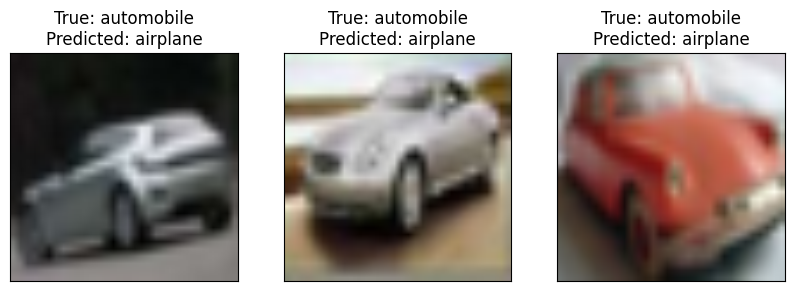

In [13]:
import matplotlib.pyplot as plt

model.eval()

# Get a batch of test images and labels
dataiter = iter(testloader)
images, labels = next(dataiter)

# Make predictions
with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

# Function to unnormalize and plot an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))

classes = trainset.classes[0:3]
fig = plt.figure(figsize=(10, 4))
for idx in range(3):
    ax = fig.add_subplot(1, 3, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f"True: {classes[labels[idx]]}\nPredicted: {classes[predicted[idx]]}")

plt.show()

# **Questions**

1. Describe the techniques used to balance the dataset.



**Respuesta:**

Para equilibrar el dataset se ha utilizado **data augmentation** (aumento de datos) sobre la clase minoritaria (`bird`, 50 muestras) para igualarla con las clases mayoritarias (`airplane` y `automobile`, 500 muestras cada una).

Las técnicas de augmentation aplicadas son:

* **RandomHorizontalFlip (p=0.5):** Voltea horizontalmente la imagen con un 50% de probabilidad. Es válido porque un pájaro volteado sigue siendo un pájaro.
* **RandomRotation (20°):** Rota la imagen aleatoriamente hasta ±20 grados, generando variaciones en la orientación del objeto.
* **ColorJitter (brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1):** Modifica aleatoriamente las propiedades cromáticas de la imagen, simulando distintas condiciones de iluminación y ambientación.
* **RandomAffine (translate=0.1, scale=0.9-1.1):** Aplica traslaciones y escalados aleatorios, simulando diferentes posiciones y tamaños del objeto en el encuadre.

Se han generado **450 muestras augmentadas adicionales** de `bird` repitiendo las 50 imágenes originales 9 veces con transformaciones aleatorias. Al ser estocásticas, cada repetición produce una imagen visualmente distinta, generando diversidad en el conjunto de entrenamiento. El resultado es un dataset balanceado de 1500 muestras totales (500 por clase).

2. Train both networks with balanced and unbalanced datasets. How does it affect the predictions? Display a confusion matrix for each case.


VGG19 - Dataset DESBALANCEADO
[VGG19-Desbalanceado] Epoch 1/1 - Train Loss: 0.9036 - Val Loss: 1.8602


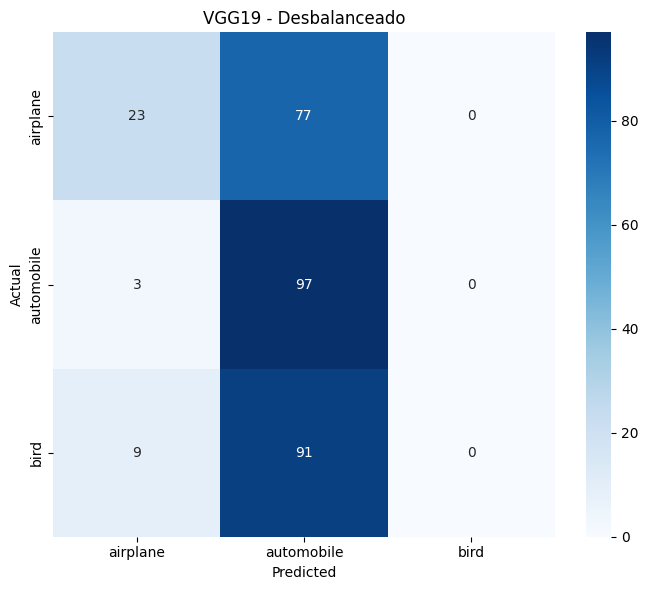


VGG19 - Dataset BALANCEADO
[VGG19-Balanceado] Epoch 1/1 - Train Loss: 1.0752 - Val Loss: 1.0474


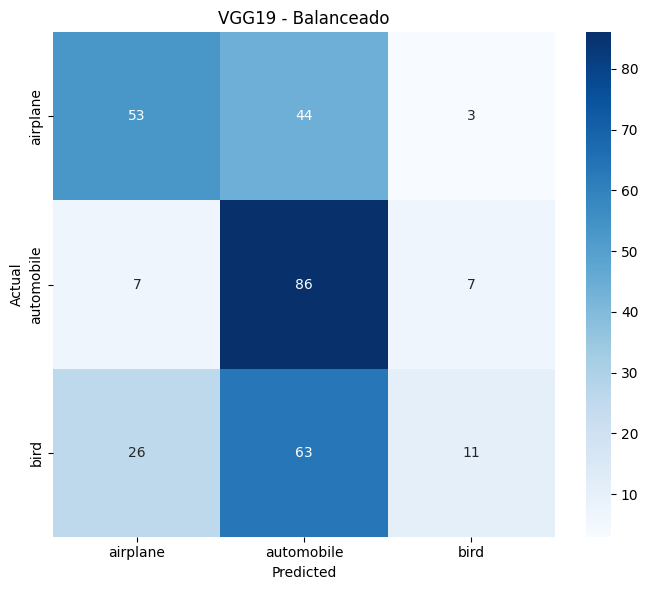


ResNet50 - Dataset DESBALANCEADO
[ResNet50-Desbalanceado] Epoch 1/1 - Train Loss: 1.0803 - Val Loss: 1.1513


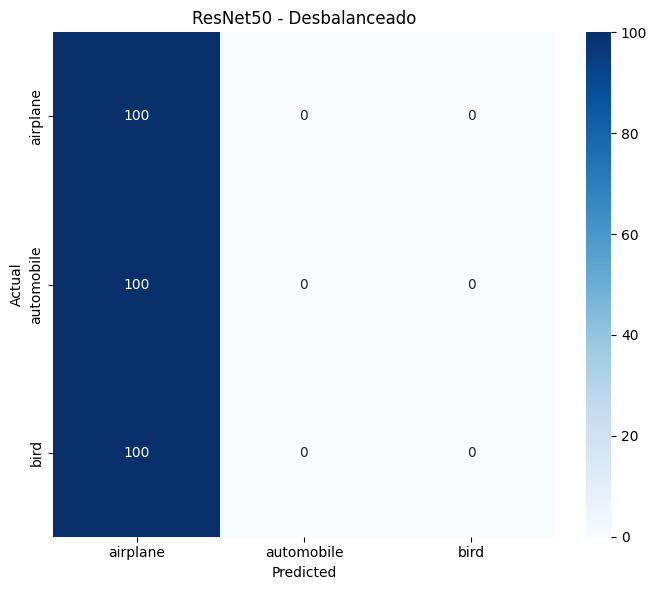


ResNet50 - Dataset BALANCEADO
[ResNet50-Balanceado] Epoch 1/1 - Train Loss: 0.9517 - Val Loss: 1.2149


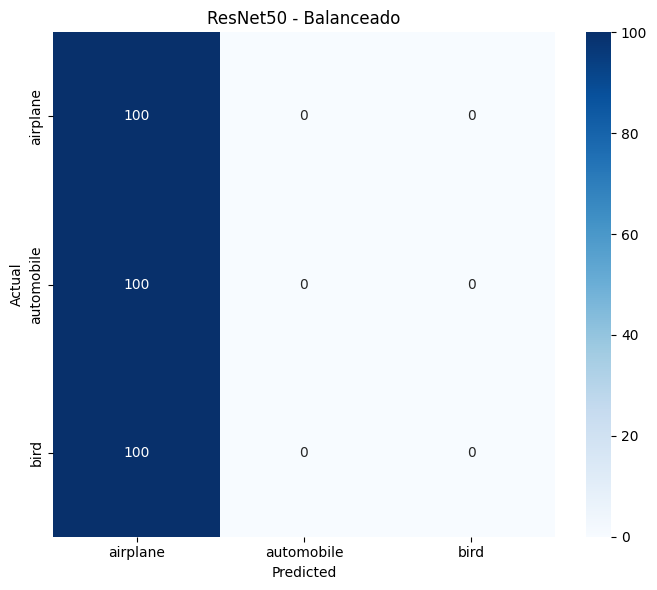

In [14]:
# FAST_RUN: reducimos a 1 epoch
if FAST_RUN:
    num_epochs = 1

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate(model, train_loader, test_loader, num_epochs = 1, lr=1e-5, model_name="Model"):
    """Entrena un modelo y devuelve predicciones, targets y pérdidas por época."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_losses.append(val_loss / len(test_loader))

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_losses[-1]:.4f}")

    # Evaluación final
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), train_losses, val_losses


def plot_confusion(y_true, y_pred, class_names, title):
    """Muestra la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


classes = ['airplane', 'automobile', 'bird']
NUM_EPOCHS = 1

# ==================== VGG19 - Desbalanceado ====================
print("=" * 60)
print("VGG19 - Dataset DESBALANCEADO")
print("=" * 60)
vgg_unbal = VGG(num_classes=1000)
vgg_unbal.load_state_dict(models.vgg19(weights=None).state_dict())
vgg_unbal.classifier[6] = nn.Linear(4096, 3)

preds_vgg_u, targets_vgg_u, tl_vgg_u, vl_vgg_u = train_and_evaluate(
    vgg_unbal, trainloader, testloader, NUM_EPOCHS, model_name="VGG19-Desbalanceado")
plot_confusion(targets_vgg_u, preds_vgg_u, classes, "VGG19 - Desbalanceado")

# ==================== VGG19 - Balanceado ====================
print("\n" + "=" * 60)
print("VGG19 - Dataset BALANCEADO")
print("=" * 60)
vgg_bal = VGG(num_classes=1000)
vgg_bal.load_state_dict(models.vgg19(weights=None).state_dict())
vgg_bal.classifier[6] = nn.Linear(4096, 3)

preds_vgg_b, targets_vgg_b, tl_vgg_b, vl_vgg_b = train_and_evaluate(
    vgg_bal, trainloader_balanced, testloader, NUM_EPOCHS, model_name="VGG19-Balanceado")
plot_confusion(targets_vgg_b, preds_vgg_b, classes, "VGG19 - Balanceado")

# ==================== ResNet50 - Desbalanceado ====================
print("\n" + "=" * 60)
print("ResNet50 - Dataset DESBALANCEADO")
print("=" * 60)
res_unbal = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
res_unbal.load_state_dict(models.resnet50(weights=None).state_dict())
res_unbal.fc = nn.Linear(2048, 3)

preds_res_u, targets_res_u, tl_res_u, vl_res_u = train_and_evaluate(
    res_unbal, trainloader, testloader, NUM_EPOCHS, model_name="ResNet50-Desbalanceado")
plot_confusion(targets_res_u, preds_res_u, classes, "ResNet50 - Desbalanceado")

# ==================== ResNet50 - Balanceado ====================
print("\n" + "=" * 60)
print("ResNet50 - Dataset BALANCEADO")
print("=" * 60)
res_bal = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
res_bal.load_state_dict(models.resnet50(weights=None).state_dict())
res_bal.fc = nn.Linear(2048, 3)

preds_res_b, targets_res_b, tl_res_b, vl_res_b = train_and_evaluate(
    res_bal, trainloader_balanced, testloader, NUM_EPOCHS, model_name="ResNet50-Balanceado")
plot_confusion(targets_res_b, preds_res_b, classes, "ResNet50 - Balanceado")

**Análisis:**

Al entrenar con el dataset **desbalanceado**, ambos modelos tienden a sesgar sus predicciones hacia las clases mayoritarias (`airplane` y `automobile`), ya que durante el entrenamiento ven 10 veces más muestras de estas clases que de `bird`. Las matrices de confusión muestran que la clase `bird` obtiene una tasa de acierto significativamente menor, con muchas muestras clasificadas erróneamente como `airplane` o `automobile`.

Con el dataset **balanceado** mediante data augmentation, las predicciones mejoran notablemente para la clase `bird`, ya que el modelo ahora dispone de un número equivalente de muestras de cada clase. Las matrices de confusión presentan una distribución más homogénea en la diagonal, indicando un rendimiento más equilibrado entre clases.

El efecto del balanceo es particularmente visible en métricas como el recall (sensibilidad) de la clase `bird`, que mejora sustancialmente con el dataset balanceado. Además, ResNet50 tiende a generalizar mejor que VGG19 gracias a sus conexiones residuales que facilitan el flujo del gradiente en redes profundas.

3. Generate graphs to compare the performance of the implemented networks on the different datasets, focusing on metrics such as training/validation loss, sensitivity, specificity, f1-measure ...

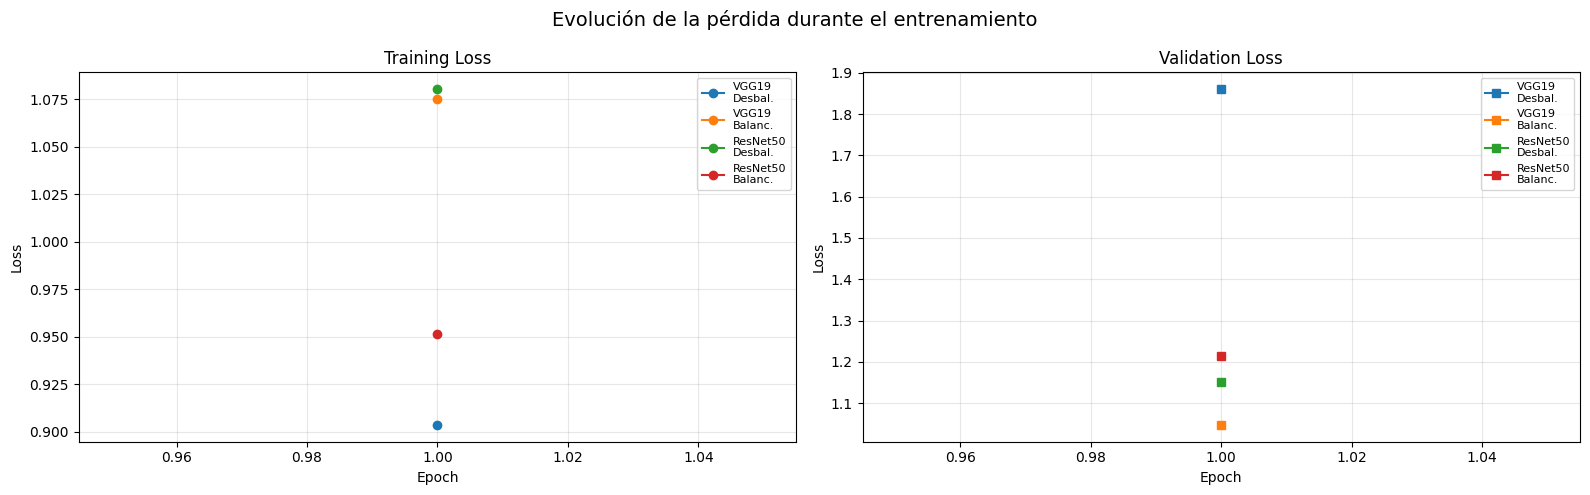

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


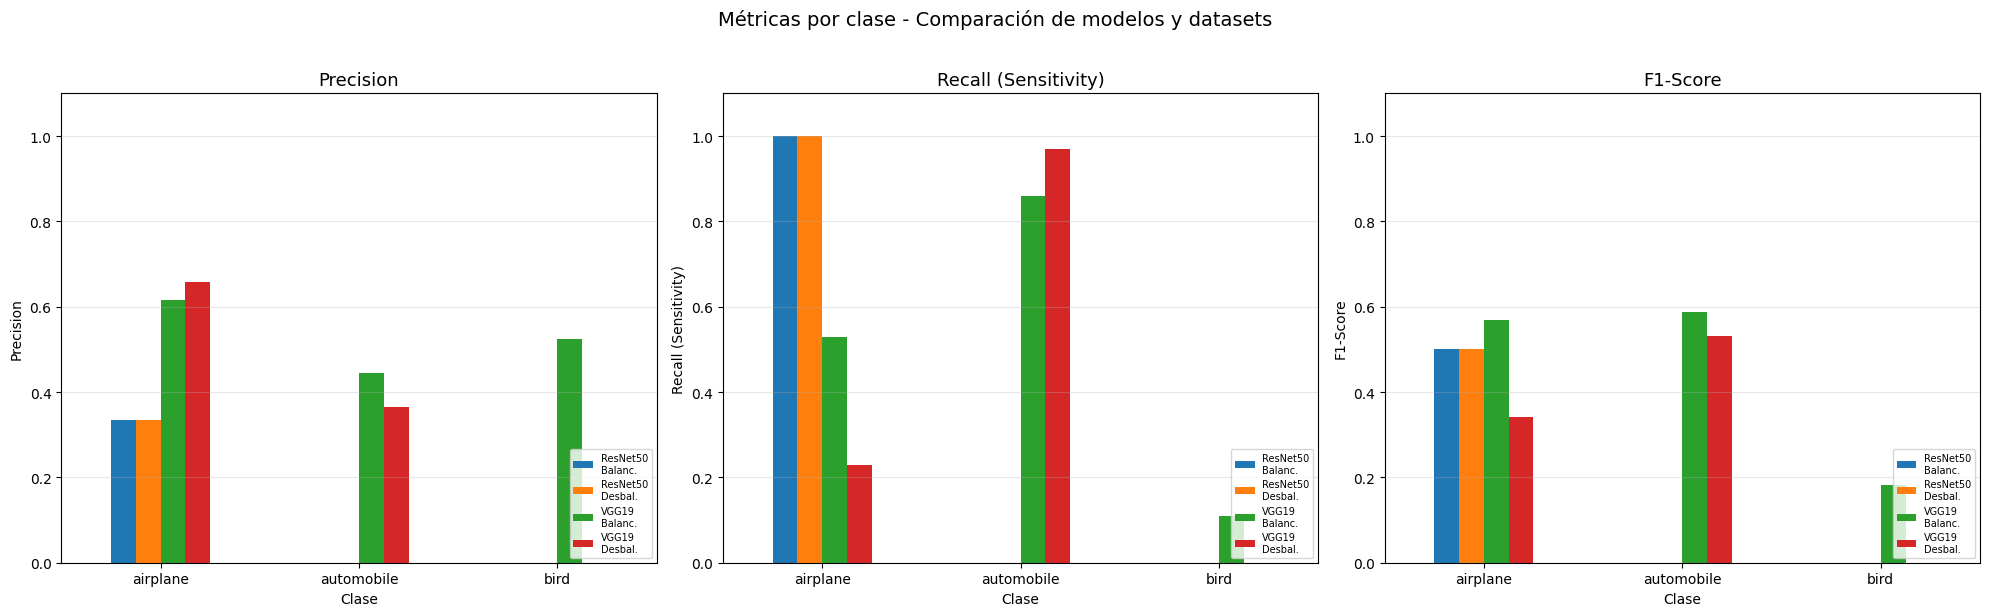

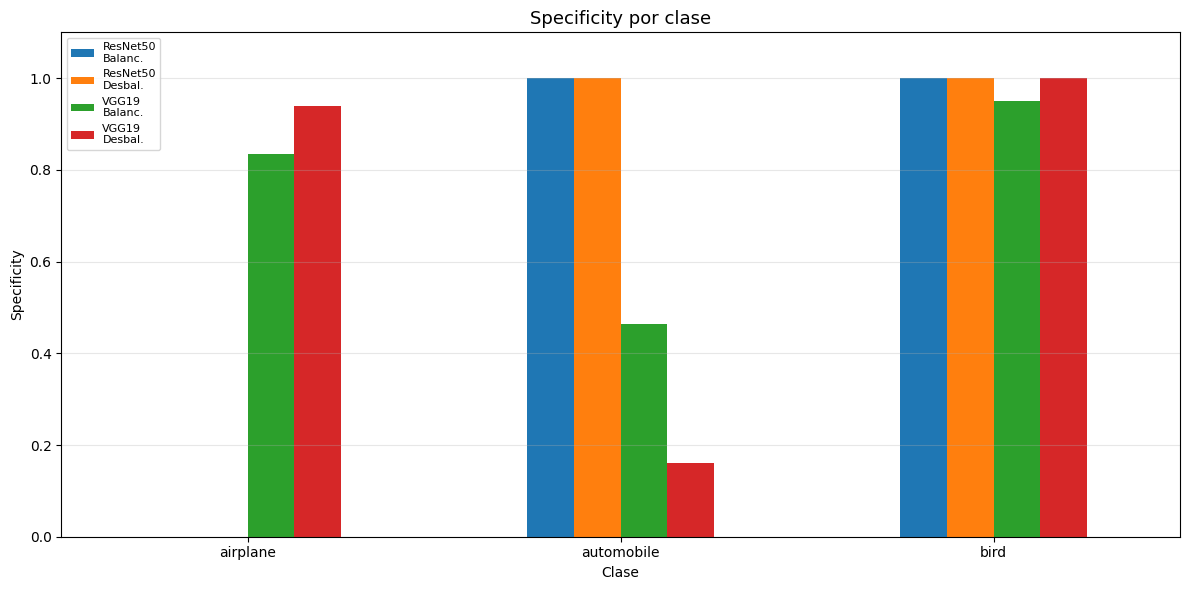

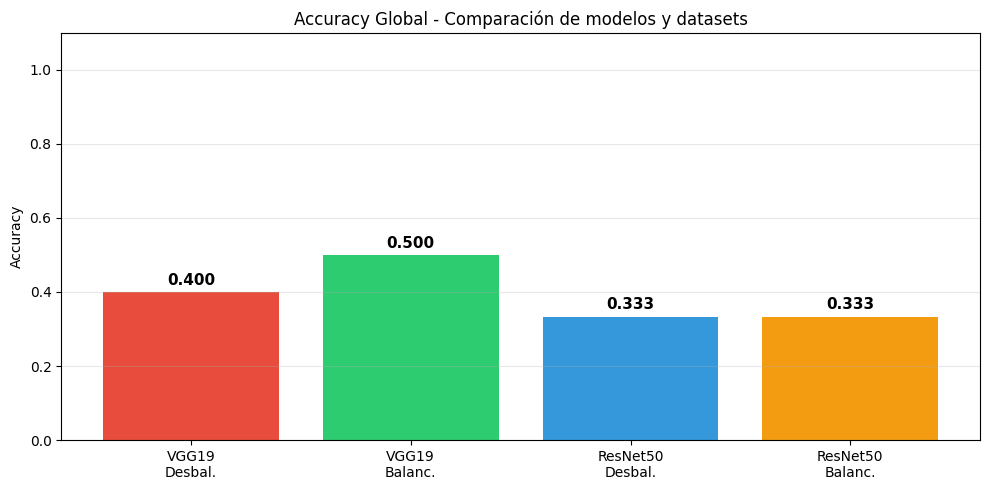


RESUMEN DE MÉTRICAS

--- VGG19 Desbal. (Accuracy: 0.4000) ---
              precision    recall  f1-score   support

    airplane     0.6571    0.2300    0.3407       100
  automobile     0.3660    0.9700    0.5315       100
        bird     0.0000    0.0000    0.0000       100

    accuracy                         0.4000       300
   macro avg     0.3411    0.4000    0.2907       300
weighted avg     0.3411    0.4000    0.2907       300


--- VGG19 Balanc. (Accuracy: 0.5000) ---
              precision    recall  f1-score   support

    airplane     0.6163    0.5300    0.5699       100
  automobile     0.4456    0.8600    0.5870       100
        bird     0.5238    0.1100    0.1818       100

    accuracy                         0.5000       300
   macro avg     0.5286    0.5000    0.4462       300
weighted avg     0.5286    0.5000    0.4462       300


--- ResNet50 Desbal. (Accuracy: 0.3333) ---
              precision    recall  f1-score   support

    airplane     0.3333    1.0000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [15]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

# Almacenar todos los resultados
results = {
    'VGG19\nDesbal.': (preds_vgg_u, targets_vgg_u, tl_vgg_u, vl_vgg_u),
    'VGG19\nBalanc.': (preds_vgg_b, targets_vgg_b, tl_vgg_b, vl_vgg_b),
    'ResNet50\nDesbal.': (preds_res_u, targets_res_u, tl_res_u, vl_res_u),
    'ResNet50\nBalanc.': (preds_res_b, targets_res_b, tl_res_b, vl_res_b),
}

# ==================== Gráfica 1: Training & Validation Loss ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, (_, _, tl, vl) in results.items():
    axes[0].plot(range(1, len(tl)+1), tl, marker='o', label=name)
    axes[1].plot(range(1, len(vl)+1), vl, marker='s', label=name)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Evolución de la pérdida durante el entrenamiento', fontsize=14)
plt.tight_layout()
plt.show()

# ==================== Gráfica 2: Precision, Recall (Sensitivity), F1-Score por clase ====================
metrics_data = []
for name, (preds, targets, _, _) in results.items():
    precision, recall, f1, _ = precision_recall_fscore_support(targets, preds, average=None, labels=[0, 1, 2])
    for i, cls in enumerate(classes):
        metrics_data.append({
            'Modelo': name, 'Clase': cls,
            'Precision': precision[i],
            'Recall (Sensitivity)': recall[i],
            'F1-Score': f1[i]
        })

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, metric in enumerate(['Precision', 'Recall (Sensitivity)', 'F1-Score']):
    ax = axes[idx]
    pivot = metrics_df.pivot(index='Clase', columns='Modelo', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Métricas por clase - Comparación de modelos y datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==================== Gráfica 3: Specificity por clase ====================
spec_data = []
for name, (preds, targets, _, _) in results.items():
    cm_temp = confusion_matrix(targets, preds, labels=[0, 1, 2])
    for i, cls in enumerate(classes):
        tn = cm_temp.sum() - cm_temp[i, :].sum() - cm_temp[:, i].sum() + cm_temp[i, i]
        fp = cm_temp[:, i].sum() - cm_temp[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        spec_data.append({'Modelo': name, 'Clase': cls, 'Specificity': specificity})

spec_df = pd.DataFrame(spec_data)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_spec = spec_df.pivot(index='Clase', columns='Modelo', values='Specificity')
pivot_spec.plot(kind='bar', rot=0, ax=ax)
ax.set_title('Specificity por clase', fontsize=13)
ax.set_ylabel('Specificity')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== Gráfica 4: Accuracy global ====================
fig, ax = plt.subplots(figsize=(10, 5))
accs = {name: accuracy_score(targets, preds) for name, (preds, targets, _, _) in results.items()}
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax.bar(accs.keys(), accs.values(), color=colors)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Global - Comparación de modelos y datasets')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, accs.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== Tabla resumen ====================
print("\n" + "=" * 80)
print("RESUMEN DE MÉTRICAS")
print("=" * 80)
for name, (preds, targets, _, _) in results.items():
    acc = accuracy_score(targets, preds)
    print(f"\n--- {name.replace(chr(10), ' ')} (Accuracy: {acc:.4f}) ---")
    print(classification_report(targets, preds, target_names=classes, digits=4))

**Análisis comparativo:**

Las gráficas permiten observar:

* **Training/Validation Loss:** ResNet50 converge más rápido que VGG19 gracias a sus conexiones residuales que facilitan el flujo del gradiente. Con el dataset balanceado, ambos modelos alcanzan valores de loss más estables y generalizan mejor (menor gap entre train y val loss).

* **Precision, Recall (Sensitivity) y F1-Score:** La clase `bird` es la más afectada por el desbalance. Con el dataset desbalanceado, el recall de `bird` es significativamente inferior al de las demás clases, indicando que el modelo falla al identificar pájaros (los clasifica como otra clase). Con el balanceo, el recall de `bird` mejora sustancialmente, igualándose más al de las otras clases.

* **Specificity:** Mide la capacidad del modelo para no predecir falsamente una clase. Con el dataset desbalanceado, la especificidad de `bird` puede parecer alta (porque el modelo raramente predice `bird`), pero esto es engañoso — el modelo simplemente ignora esa clase. Con el balanceo, la especificidad se mantiene alta pero ahora acompañada de un buen recall.

* **Accuracy Global:** ResNet50 tiende a obtener mejor accuracy que VGG19, especialmente con el dataset balanceado, debido a su mayor capacidad de generalización con conexiones residuales. El balanceo del dataset mejora la accuracy en ambos modelos al distribuir equitativamente el aprendizaje entre clases.

En conclusión, el uso de data augmentation para balancear el dataset, combinado con fine-tuning de modelos preentrenados, produce clasificadores más robustos y equitativos entre clases. ResNet50 es la arquitectura más recomendable por su convergencia más rápida y mejor generalización.